<a href="https://colab.research.google.com/github/TeeterJL/INFO648/blob/main/INFO648%5CHW%5CProblem_Set_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 648_HW 3_Teeter, Jacob

First thing i do is import all of my additional tools

In [178]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [179]:
df=pd.read_csv("/content/cps_with_education-1 (1) (1).csv")

In [180]:
df['education'].unique()

array(['Some College', 'Less than HS', "Bachelor's", "Associate's",
       "Master's", 'NIU / Child', 'Graduate / Professional',
       'High School'], dtype=object)

In [181]:
df.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,5.553935e+06,5.553935e+06,5.553935e+06,5.553935e+06,5.553935e+06,5.553935e+06,5.553935e+06
mean,2.776967e+06,2.023274e+03,5.726636e+02,7.483270e+05,4.126219e+01,1.511838e+00,2.815773e+01
std,1.603283e+06,1.280121e+00,4.769100e+02,4.338282e+05,2.359497e+01,4.998599e-01,1.629995e+01
min,0.000000e+00,2.020000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,1.388484e+06,2.022000e+03,4.000000e+01,3.840000e+03,2.100000e+01,1.000000e+00,1.300000e+01
50%,2.776967e+06,2.023000e+03,9.990000e+02,1.000000e+06,4.100000e+01,2.000000e+00,2.800000e+01
75%,4.165450e+06,2.024000e+03,9.990000e+02,1.000000e+06,6.100000e+01,2.000000e+00,4.200000e+01
max,5.553934e+06,2.025000e+03,9.990000e+02,1.000000e+06,8.500000e+01,2.000000e+00,5.600000e+01


Now i have to clean the data. I'll have to clean up the age range, UHRSWORKT min and max, and EARNWEEK2 range

In [182]:
df_clean=df[(df['UHRSWORKT'].between(1,80)) & (df['AGE']>=18)].copy()
df_clean.loc[df_clean['EARNWEEK2']>99999,'EARNWEEK2']=pd.NA
df_clean.loc[df_clean['EARNWEEK2']<1,'EARNWEEK2']=pd.NA
df_clean = df_clean[df_clean['EARNWEEK2'].notna()]
#df_clean.describe()

Now that i have a cleaned baseline data frame; i need to bvreak it down into my groups.

I start with making DFs for the years 2024 and 2025. Then i break each year down further into male and female.

Leaving me with 4 total groups, sparated by year and gender.

In [183]:
df_2024=df_clean[df_clean['YEAR']==2024].copy()
df_2025=df_clean[df_clean['YEAR']==2025].copy()
men_2024=df_2024[df_2024['SEX']==1].copy()
men_2025=df_2025[df_2025['SEX']==1].copy()
women_2024=df_2024[df_2024['SEX']==2].copy()
women_2025=df_2025[df_2025['SEX']==2].copy()

Now that i have my group, i can run the statistics to see the surface level differences in Tukey's 5 number summary.

Male 2024

In [184]:
men_2024.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,6.207400e+04,62074.0,62074.000000,62074.000000,62074.000000,62074.0,62074.000000
mean,3.740065e+06,2024.0,40.694059,1634.868266,42.737507,1.0,28.405403
std,3.830946e+05,0.0,9.362747,1689.016960,14.342871,0.0,16.356703
min,3.076326e+06,2024.0,1.000000,4.000000,18.000000,1.0,1.000000
25%,3.377634e+06,2024.0,40.000000,770.000000,31.000000,1.0,13.000000
50%,3.768786e+06,2024.0,40.000000,1200.000000,42.000000,1.0,29.000000
75%,4.062656e+06,2024.0,40.000000,1920.000000,54.000000,1.0,42.000000
max,4.369965e+06,2024.0,80.000000,11952.530000,85.000000,1.0,56.000000


Male 2025

In [185]:
men_2025.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,5.220900e+04,52209.0,52209.000000,52209.000000,52209.000000,52209.0,52209.000000
mean,4.994408e+06,2025.0,40.644736,1747.655466,42.792354,1.0,28.371239
std,3.533288e+05,0.0,9.462916,1873.947965,14.344333,0.0,16.276030
min,4.369979e+06,2025.0,1.000000,4.000000,18.000000,1.0,1.000000
25%,4.631087e+06,2025.0,40.000000,800.000000,31.000000,1.0,13.000000
50%,5.030833e+06,2025.0,40.000000,1250.000000,42.000000,1.0,29.000000
75%,5.297624e+06,2025.0,40.000000,1960.000000,54.000000,1.0,42.000000
max,5.553861e+06,2025.0,80.000000,13258.230000,85.000000,1.0,56.000000


Female 2024

In [186]:
women_2024.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,5.982900e+04,59829.0,59829.000000,59829.000000,59829.000000,59829.0,59829.000000
mean,3.738473e+06,2024.0,37.580371,1236.307805,43.218138,2.0,28.198967
std,3.836125e+05,0.0,9.915905,1277.977938,14.329897,0.0,16.242302
min,3.076330e+06,2024.0,1.000000,4.000000,18.000000,2.0,1.000000
25%,3.368238e+06,2024.0,36.000000,600.000000,31.000000,2.0,13.000000
50%,3.768069e+06,2024.0,40.000000,924.000000,42.000000,2.0,29.000000
75%,4.061963e+06,2024.0,40.000000,1440.000000,54.000000,2.0,42.000000
max,4.369966e+06,2024.0,80.000000,11952.530000,85.000000,2.0,56.000000


Female 2025

In [187]:
women_2025.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,5.029200e+04,50292.0,50292.000000,50292.000000,50292.000000,50292.0,50292.000000
mean,4.989772e+06,2025.0,37.497952,1295.201669,43.335461,2.0,28.265987
std,3.544926e+05,0.0,9.915622,1385.336821,14.329541,0.0,16.154470
min,4.369980e+06,2025.0,1.000000,4.000000,18.000000,2.0,1.000000
25%,4.624376e+06,2025.0,36.000000,624.000000,32.000000,2.0,13.000000
50%,5.025500e+06,2025.0,40.000000,962.000000,43.000000,2.0,29.000000
75%,5.295100e+06,2025.0,40.000000,1540.000000,55.000000,2.0,42.000000
max,5.553888e+06,2025.0,80.000000,13258.230000,85.000000,2.0,56.000000


#Part A — Winsorization (Outlier Handling)

To winsorize my gender and year groups, i assign the cutoff value as the 95th quantile of EARNWEEK2.

In [188]:
m_2024_cut=men_2024['EARNWEEK2'].quantile(.95)
m_2025_cut=men_2025['EARNWEEK2'].quantile(.95)
w_2024_cut=women_2024['EARNWEEK2'].quantile(.95)
w_2025_cut=women_2025['EARNWEEK2'].quantile(.95)
print(f'Winsorization outlier handling numbers:\nm_2024_cut={m_2024_cut}\nm_2025_cut={m_2025_cut}\nw_2024_cut={w_2024_cut}\nw_2025_cut={w_2025_cut}')


Winsorization outlier handling numbers:
m_2024_cut=3660.0
m_2025_cut=3900.0
w_2024_cut=2880.0
w_2025_cut=3000.0


To find the sample size, i run a size count command, but i preceed that command with a print function and a filter option to only show "EARNWEEK2" sample, since that is the data that out cutoff value is based off of.

In [189]:
print(f"men_2024 sample size: {men_2024['EARNWEEK2'].count()}")
print(f"men_2025 sample size: {men_2025['EARNWEEK2'].count()}")
print(f"women_2024 sample size: {women_2024['EARNWEEK2'].count()}")
print(f"women_2025 sample size: {women_2025['EARNWEEK2'].count()}")

men_2024 sample size: 62074
men_2025 sample size: 52209
women_2024 sample size: 59829
women_2025 sample size: 50292


Next I need to make a table to display the above data, so i make a pandas dataframe using the output from the code cells above. Then just create a simple table.

I also want to format the cutoff value in dollars so i use 'Cutoff (95th pct)': '${:,.0f}' to do so

In [190]:
Part_A_Table = pd.DataFrame({
    'Group':['Men-2024','Men-2025','Women-2024','Women-2025'],
    'Cutoff (95th pct)':[m_2024_cut, m_2025_cut, w_2024_cut, w_2025_cut],
    'Sample size n':[men_2024['EARNWEEK2'].count(),
                          men_2025['EARNWEEK2'].count(),
                          women_2024['EARNWEEK2'].count(),
                          women_2025['EARNWEEK2'].count()],})

In [191]:
Part_A_Table.style.hide().format({'Cutoff (95th pct)': '${:,.0f}'})

Group,Cutoff (95th pct),Sample size n
Men-2024,"$3,660",62074
Men-2025,"$3,900",52209
Women-2024,"$2,880",59829
Women-2025,"$3,000",50292


Lastly, before moving on the the next step i am going to create a copy data frame that replaces the outliers with the cutoff value, so i can use this df for future parts in the HW.

In [192]:
# Men 2024
men_2024 = men_2024.copy()
men_2024['EARNWEEK2_w95'] = men_2024['EARNWEEK2']
men_2024.loc[men_2024['EARNWEEK2'] > m_2024_cut, 'EARNWEEK2_w95'] = m_2024_cut

# Men 2025
men_2025 = men_2025.copy()
men_2025['EARNWEEK2_w95'] = men_2025['EARNWEEK2']
men_2025.loc[men_2025['EARNWEEK2'] > m_2025_cut, 'EARNWEEK2_w95'] = m_2025_cut

# Women 2024
women_2024 = women_2024.copy()
women_2024['EARNWEEK2_w95'] = women_2024['EARNWEEK2']
women_2024.loc[women_2024['EARNWEEK2'] > w_2024_cut, 'EARNWEEK2_w95'] = w_2024_cut

# Women 2025
women_2025 = women_2025.copy()
women_2025['EARNWEEK2_w95'] = women_2025['EARNWEEK2']
women_2025.loc[women_2025['EARNWEEK2'] > w_2025_cut, 'EARNWEEK2_w95'] = w_2025_cut

print(men_2024['EARNWEEK2_w95'].max(), m_2024_cut)
print(men_2025['EARNWEEK2_w95'].max(), m_2025_cut)
print(women_2024['EARNWEEK2_w95'].max(), w_2024_cut)
print(women_2025['EARNWEEK2_w95'].max(), w_2025_cut)

3660.0 3660.0
3900.0 3900.0
2880.0 2880.0
3000.0 3000.0


Now i just run a .head command to make sure my new collum works

In [193]:
men_2024.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,EARNWEEK2_w95
3076326,3076326,2024,40,520.0,36,1,1,Some College,520.0
3076334,3076334,2024,12,220.0,69,1,1,Some College,220.0
3076344,3076344,2024,40,2880.0,64,1,1,Graduate / Professional,2880.0
3076347,3076347,2024,60,1730.0,58,1,1,Some College,1730.0
3076349,3076349,2024,40,880.0,47,1,1,Bachelor's,880.0


# Part B — Confidence Intervals for Population Mean Earnings

To calculate the 95% confidence intervals for the group, first i have to find the sample size, mean, and standard deviation

In [194]:
sample_size_men_2024=len(men_2024['EARNWEEK2_w95'])
mean_men_2024=men_2024['EARNWEEK2_w95'].mean()
std_men_2024=men_2024['EARNWEEK2_w95'].std()
print(f'men_2024:\nsample size={sample_size_men_2024}\nmean={mean_men_2024}\nstd={std_men_2024}\n')
___
sample_size_men_2025=len(men_2025['EARNWEEK2_w95'])
mean_men_2025=men_2025['EARNWEEK2_w95'].mean()
std_men_2025=men_2025['EARNWEEK2_w95'].std()
print(f'men_2025:\nsample size={sample_size_men_2025}\nmean={mean_men_2025}\nstd={std_men_2025}\n')
___
sample_size_women_2024=len(women_2024['EARNWEEK2_w95'])
mean_women_2024=women_2024['EARNWEEK2_w95'].mean()
std_women_2024=women_2024['EARNWEEK2_w95'].std()
print(f'women_2024:\nsample size={sample_size_women_2024}\nmean={mean_women_2024}\nstd={std_women_2024}\n')
___
sample_size_women_2025=len(women_2025['EARNWEEK2_w95'])
mean_women_2025=women_2025['EARNWEEK2_w95'].mean()
std_women_2025=women_2025['EARNWEEK2_w95'].std()
print(f'women_2025:\nsample size={sample_size_women_2025}\nmean={mean_women_2025}\nstd={std_women_2025}\n')

men_2024:
sample size=62074
mean=1434.9088686084351
std=904.7239742811805

men_2025:
sample size=52209
mean=1510.0620889118734
std=974.4667945148494

women_2024:
sample size=59829
mean=1117.6461889719033
std=715.8491159085028

women_2025:
sample size=50292
mean=1158.0317664837348
std=745.8232730684495



Now i find the z value that will be used for 95% CI. Then i can caluculate he upper and lower bound of the confidence interval

In [195]:
from scipy.stats import norm
z=norm.ppf(1-.025)
#men_2024
CI_lower_men_2024=mean_men_2024-z*(std_men_2024/np.sqrt(sample_size_men_2024))
CI_upper_men_2024=mean_men_2024+z*(std_men_2024/np.sqrt(sample_size_men_2024))

#men_2025
CI_lower_men_2025=mean_men_2025-z*(std_men_2025/np.sqrt(sample_size_men_2025))
CI_upper_men_2025=mean_men_2025+z*(std_men_2025/np.sqrt(sample_size_men_2025))

#women_2024
CI_lower_women_2024=mean_women_2024-z*(std_women_2024/np.sqrt(sample_size_women_2024))
CI_upper_women_2024=mean_women_2024+z*(std_women_2024/np.sqrt(sample_size_women_2024))

#women_2025
CI_lower_women_2025=mean_women_2025-z*(std_women_2025/np.sqrt(sample_size_women_2025))
CI_upper_women_2025=mean_women_2025+z*(std_women_2025/np.sqrt(sample_size_women_2025))

print(f'men_2024_95% Confidence Interval:\nCI lower={CI_lower_men_2024}\nCI upper={CI_upper_men_2024}\n')
print(f'men_2025_95% Confidence Interval:\nCI lower={CI_lower_men_2025}\nCI upper={CI_upper_men_2025}\n')
print(f'women_2024_95% Confidence Interval:\nCI lower={CI_lower_women_2024}\nCI upper={CI_upper_women_2024}\n')
print(f'women_2025_95% Confidence Interval:\nCI lower={CI_lower_women_2025}\nCI upper={CI_upper_women_2025}\n')


men_2024_95% Confidence Interval:
CI lower=1427.791666087373
CI upper=1442.0260711294973

men_2025_95% Confidence Interval:
CI lower=1501.7033175047786
CI upper=1518.4208603189682

women_2024_95% Confidence Interval:
CI lower=1111.9101286219072
CI upper=1123.3822493218993

women_2025_95% Confidence Interval:
CI lower=1151.5134631202627
CI upper=1164.550069847207



A 95% confidence interval means that if you draw samples of the weekly earnings of a group and calculated confidence intervals each time, that about 95% of those intervals would capture the true population mean.

For 2024 both the male iterval \(1,427.79–1,442.03) and the female interval (1,111.91–1,123.38) are beneath the 2025 intervals for male and female. With 2025 intervals being (1,501.70–1,518.42) for male and (1,151.51–1,164.55) for female, there is no overlap between years for either genders. This means that 2025 has a higher mean and that threre is likely a real upward trend in average weekly earnings in 2025.

# Part C — Hypothesis Tests: Did the Population Mean Change?

In [196]:
from scipy.stats import ttest_ind, ttest_1samp

**Men Hypothesis:**

Ho: μ_men_2025-μ_men_2024 = 0

Ha: μ_men_2025-μ_men_2024 NOT= 0

**Female Hypothesis:**

Ho: μ_women_2025-μ_women_2024 = 0

Ha: μ_women_2025-μ_women_2024 NOT= 0




Now i can run my two side hypothesis test to determine if the difference between 2024 and 2025 average earnings is statisitcally significant or not.


In [197]:
from scipy.stats import ttest_ind
#Male Hypothesis test
ttest_ind(men_2025['EARNWEEK2_w95'], men_2024['EARNWEEK2_w95'], equal_var=False)

TtestResult(statistic=np.float64(13.41712858541208), pvalue=np.float64(5.178271590784075e-41), df=np.float64(107726.37138773143))

In [198]:
#Female hypothesis test
ttest_ind(women_2025['EARNWEEK2_w95'], women_2024['EARNWEEK2_w95'], equal_var=False)

TtestResult(statistic=np.float64(9.116236755963454), pvalue=np.float64(7.909478329754109e-20), df=np.float64(105272.57901261482))

In [199]:
men_p_value = np.float64(5.178271590784075e-41)
Women_p_value = pvalue=np.float64(7.909478329754109e-20)
men_delta = (mean_men_2024-mean_men_2025)
women_delta = (mean_women_2024-mean_women_2025)
print(f'Hypothesis Test Results: \nMen_2024 sample mean={mean_men_2024}\nMen_Delta={men_delta}\nMen_P_value={men_p_value}\n')
print(f'Women_2024 sample mean={mean_women_2024}\nWomen_Delta={women_delta}\nWomen_P_value={Women_p_value}\n')

Hypothesis Test Results: 
Men_2024 sample mean=1434.9088686084351
Men_Delta=-75.15322030343827
Men_P_value=5.178271590784075e-41

Women_2024 sample mean=1117.6461889719033
Women_Delta=-40.38557751183157
Women_P_value=7.909478329754109e-20



The results of both hypothesis test come back the same; reject the null hypothesis. Both p values are significantly below the .05 threshhold, meaning that the average weekly earnings changed significantly from 2024 to 2025 for both sexes and that the difference between the two years is not a product of random dsample variation but is actually a real change in the population.

# Part D — Statistical vs. Practical Significance

In [200]:
# Calculate pooled standard deviation for men
sp_men = np.sqrt(((sample_size_men_2024 - 1) * std_men_2024**2 + (sample_size_men_2025 - 1) * std_men_2025**2) / (sample_size_men_2024 + sample_size_men_2025 - 2))

# Calculate Cohen's d for men
cohens_d_men = (mean_men_2025 - mean_men_2024) / sp_men

# Calculate pooled standard deviation for women
sp_women = np.sqrt(((sample_size_women_2024 - 1) * std_women_2024**2 + (sample_size_women_2025 - 1) * std_women_2025**2) / (sample_size_women_2024 + sample_size_women_2025 - 2))

# Calculate Cohen's d for women
cohens_d_women = (mean_women_2025 - mean_women_2024) / sp_women

print(f"Cohen's d for men: {cohens_d_men:.2f}")
print(f"Cohen's d for women: {cohens_d_women:.2f}")

# Interpret Cohen's d
def interpret_cohens_d(d_value):
    abs_d = abs(d_value)
    if abs_d < 0.2:
        return "a trivial effect."
    elif abs_d < 0.5:
        return "a small effect."
    elif abs_d < 0.8:
        return "a medium effect."
    else:
        return "a large effect."

print(f"The effect size for men's weekly earnings is {interpret_cohens_d(cohens_d_men)}")
print(f"The effect size for women's weekly earnings is {interpret_cohens_d(cohens_d_women)}")

Cohen's d for men: 0.08
Cohen's d for women: 0.06
The effect size for men's weekly earnings is a trivial effect.
The effect size for women's weekly earnings is a trivial effect.


In [201]:
men_change_in_W_Mean = ((mean_men_2025-mean_men_2024)/mean_men_2024*100)
women_change_in_W_Mean = ((mean_women_2025-mean_women_2024)/mean_women_2024*100)
print(f'Male_Change_in_Wmean:\n{men_change_in_W_Mean:.2f}%\n')
print(f'Female_Change_in_Wmean:\n{women_change_in_W_Mean:.2f}%\n')

Male_Change_in_Wmean:
5.24%

Female_Change_in_Wmean:
3.61%



Cohen's d value for both men and women was extremely small, even when compared to the "small" benchmark of .2. Men had a d value of .08 and women had .06, meaning that from 2024 to 2025 average weekly earnings shifted by less than 1/10 of a standard deviaiton. The p values for both sexes were very small because the sample size was enormous (hundreds of thousands) and d measures how big that difference actually is while not letting sample size skew the analysis. So while there is real statistical significance in the change of weekly earnings from 2024 to 2025, it is so small that the changes ends up not really mattering demonstrating practical significance.

# Part E — CPI Check: Are Earnings “Keeping Up”?

The male winsorized weekly earnings mean rose 5.24% from 2024 to 2025 and women's rose 3.61%, whioch shows that both genders are exceeding the 2.7% increase of the CPI. The largest difference between the groups is that the male earnings grew more than 4x as fast as womens. However, these are winsorized means, so the top earners or "outliers" have been replaced with the curoff values so the true population change percentages would likely differ.

# Part F — Plots

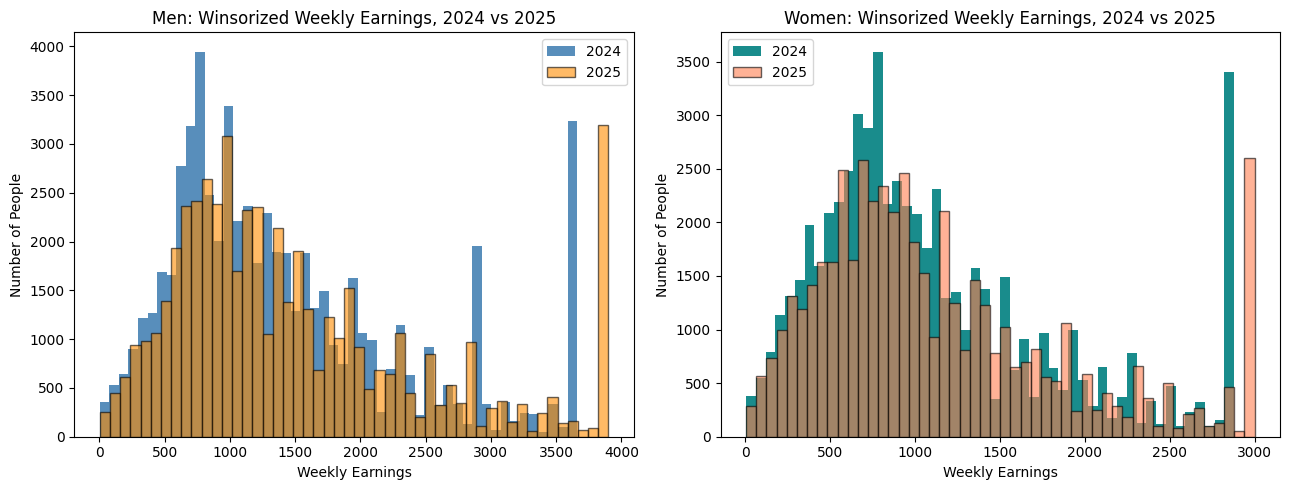

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Men
axes[0].hist(men_2024['EARNWEEK2_w95'], bins=50, alpha=0.9, label='2024', color='steelblue')
axes[0].hist(men_2025['EARNWEEK2_w95'], bins=50, alpha=0.6, label='2025', color='darkorange',edgecolor='black')
axes[0].set_title("Men: Winsorized Weekly Earnings, 2024 vs 2025")
axes[0].set_xlabel("Weekly Earnings")
axes[0].set_ylabel("Number of People")
axes[0].legend()

# Women
axes[1].hist(women_2024['EARNWEEK2_w95'], bins=50, alpha=0.9, label='2024', color='teal')
axes[1].hist(women_2025['EARNWEEK2_w95'], bins=50, alpha=0.6, label='2025', color='coral',edgecolor='black')
axes[1].set_title("Women: Winsorized Weekly Earnings, 2024 vs 2025")
axes[1].set_xlabel("Weekly Earnings")
axes[1].set_ylabel("Number of People")
axes[1].legend()

plt.tight_layout()
plt.show()

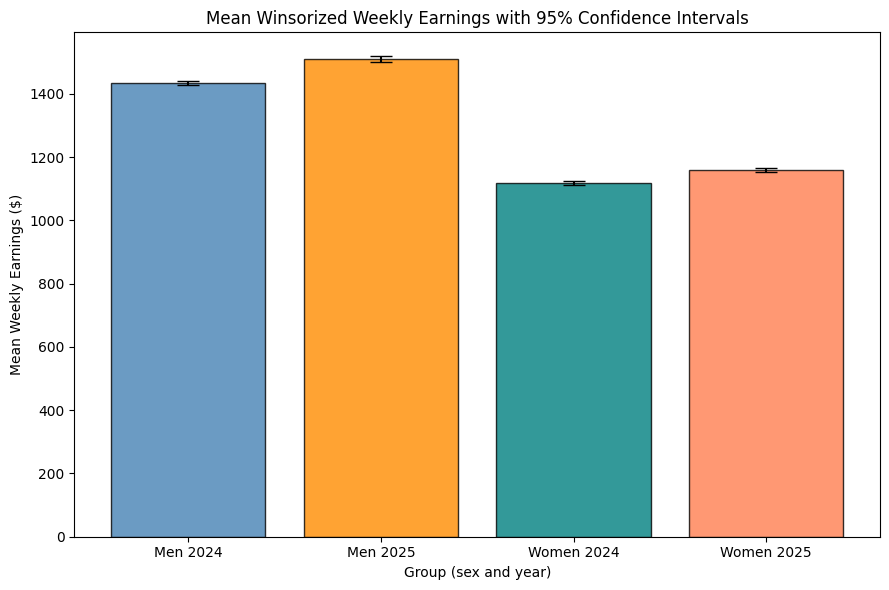

In [238]:
groups = ['Men 2024', 'Men 2025', 'Women 2024', 'Women 2025']
means  = [mean_men_2024, mean_men_2025, mean_women_2024, mean_women_2025]
errors = [mean_men_2024   - CI_lower_men_2024,
    mean_men_2025   - CI_lower_men_2025,
    mean_women_2024 - CI_lower_women_2024,
    mean_women_2025 - CI_lower_women_2025,]
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue', 'darkorange', 'teal', 'coral']
ax.bar(groups, means, yerr=errors, capsize=8, color=colors, alpha=0.8, edgecolor='black')
ax.set_title("Mean Winsorized Weekly Earnings with 95% Confidence Intervals")
ax.set_xlabel("Group (sex and year)")
ax.set_ylabel("Mean Weekly Earnings ($)")
plt.tight_layout()
plt.show()

The histograms show that weekly esarning are strongly right skewed, even with the winsored means, meaning that a majority of people are on the lower end of the earning scale and that both distrobutions are nearly identical, giving credence toward the cohen d value being very small.

In the bar graph, the confidence interval error bars are very small compared to the size of the bars, meaning the sample size is so large that it makes the means extremely precise which is misleading  especially when considering the cohen d value.